## Complete Notes on **LangGraph**

**LangGraph** is a framework used to build **stateful, multi-step AI workflows using LLMs**.
It is mainly used with **LangChain** to create **agent workflows that follow a graph structure instead of a simple chain**.

It allows developers to design **complex AI systems with loops, decision points, memory, and multiple agents**.

---

# 1. What is LangGraph?

**LangGraph** is a **graph-based orchestration framework** for LLM applications.

Instead of a simple pipeline:

```
Input → LLM → Output
```

LangGraph allows **dynamic flows**:

```
Start → Agent → Tool → Decision → Agent → Output
```

This means the system can:

* make decisions
* loop
* use tools
* store memory
* collaborate with multiple agents

---

# 2. Why LangGraph is Needed

Traditional **LangChain chains** are **linear**.

Example:

```
Prompt → LLM → Result
```

But real AI systems require:

* Decision making
* Loops
* Error handling
* Multi-agent collaboration

LangGraph solves this by using a **graph structure**.

Example workflow:

```
        ┌──── Tool ────┐
Start → Agent → Decide → End
        └──── Retry ───┘
```

---

# 3. Core Concepts of LangGraph

### 1. Graph

The main workflow structure.

It contains:

* nodes
* edges
* state

---

### 2. Nodes

Nodes represent **tasks or functions**.

Examples:

* LLM call
* tool execution
* decision function

Example node:

```python
def chatbot(state):
    return {"message": llm.invoke(state["message"])}
```

---

### 3. Edges

Edges define **how nodes connect**.

Example:

```
Node A → Node B
```

Conditional edges allow **branching decisions**.

Example:

```
if success → END
if fail → retry
```

---

### 4. State

State is **shared data passed between nodes**.

Example state:

```python
{
 "message": "Hello",
 "history": []
}
```

Each node **reads and updates the state**.

---

### 5. Start and End Nodes

Every graph must define:

```
START → workflow → END
```

---

# 4. LangGraph Architecture

```
User Input
     │
     ▼
 START NODE
     │
     ▼
 LLM AGENT
     │
     ▼
 TOOL CALL
     │
     ▼
 DECISION NODE
   │       │
   ▼       ▼
 Retry     END
```

---

# 5. Installation

```bash
pip install langgraph langchain openai
```

---

# 6. Simple LangGraph Example

### Example: Chatbot Workflow

```python
from langgraph.graph import StateGraph, END
from typing import TypedDict

class ChatState(TypedDict):
    message: str

def chatbot(state):
    msg = state["message"]
    return {"message": f"Bot: You said {msg}"}

graph = StateGraph(ChatState)

graph.add_node("chatbot", chatbot)

graph.set_entry_point("chatbot")

graph.add_edge("chatbot", END)

app = graph.compile()

result = app.invoke({"message": "Hello"})
print(result)
```

Output

```
Bot: You said Hello
```

---

# 7. Example with Decision Node

Example workflow:

```
User Question
      │
      ▼
   LLM Node
      │
      ▼
  Decision Node
   │        │
   ▼        ▼
Tool      End
```

### Code

```python
from langgraph.graph import StateGraph, END
from typing import TypedDict

class State(TypedDict):
    question: str
    decision: str

def agent(state):
    if "weather" in state["question"]:
        return {"decision": "tool"}
    return {"decision": "end"}

def tool(state):
    return {"answer": "Weather is 25°C"}

graph = StateGraph(State)

graph.add_node("agent", agent)
graph.add_node("tool", tool)

graph.set_entry_point("agent")

def decide(state):
    if state["decision"] == "tool":
        return "tool"
    return END

graph.add_conditional_edges(
    "agent",
    decide
)

graph.add_edge("tool", END)

app = graph.compile()
```

---

# 8. Multi-Agent Workflow Example

LangGraph supports **multiple agents collaborating**.

Example:

```
User Question
     │
     ▼
 Planner Agent
     │
     ▼
 Research Agent
     │
     ▼
 Writer Agent
     │
     ▼
 Final Answer
```

Agents:

1. Planner → breaks problem
2. Researcher → collects data
3. Writer → generates response

---

# 9. Memory in LangGraph

LangGraph supports **long-term memory**.

Types:

1. Conversation memory
2. Session memory
3. Vector memory (RAG)

Example:

```python
state["history"].append(user_message)
```

---

# 10. LangGraph vs LangChain

| Feature     | LangChain    | LangGraph |
| ----------- | ------------ | --------- |
| Structure   | Linear chain | Graph     |
| Loops       | Limited      | Yes       |
| Agents      | Basic        | Advanced  |
| Memory      | Basic        | Stateful  |
| Multi-agent | Hard         | Easy      |

---

# 11. Real Use Cases

LangGraph is used for:

### AI Agents

Autonomous assistants.

### Customer Support Bots

Multi-step reasoning.

### Research Assistants

Gather → analyze → summarize.

### Coding Agents

Plan → write → debug code.

---

# 12. Advantages

* Stateful workflows
* Loop support
* Multi-agent architecture
* Flexible decision making
* Better debugging

---

# 13. Limitations

* Slightly complex setup
* Requires understanding graph logic
* Debugging large graphs can be tricky

---

# 14. When to Use LangGraph

Use LangGraph when:

* building **AI agents**
* implementing **complex workflows**
* creating **multi-step reasoning systems**
* building **multi-agent collaboration systems**

---

# 15. Real Example Workflow (Research Agent)

```
User Query
   │
   ▼
Planner Agent
   │
   ▼
Search Tool
   │
   ▼
Summarizer
   │
   ▼
Final Answer
```

---

# 16. Summary

LangGraph is a **powerful framework for building intelligent AI systems with complex workflows**.

Key points:

* Graph-based AI workflows
* Stateful execution
* Supports loops and branching
* Ideal for AI agents and multi-step reasoning

---

## **LangGraph Architecture Diagram (Easy for Exams)**

LangGraph uses a **graph-based workflow architecture** where different nodes (tasks) are connected with edges (flow of execution).

### Simple Architecture Diagram

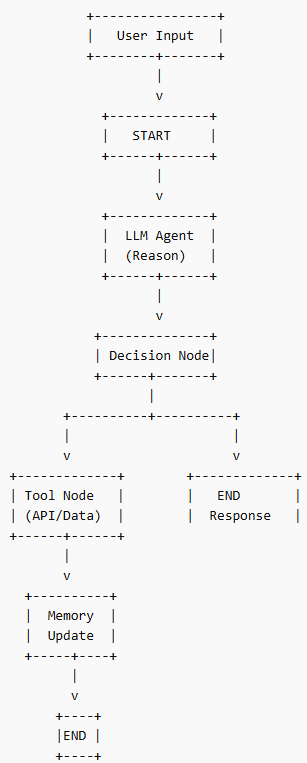

### Explanation of Components

| Component          | Description                                  |
| ------------------ | -------------------------------------------- |
| **Start Node**     | Entry point of the workflow                  |
| **LLM Agent Node** | Processes the user query using an LLM        |
| **Decision Node**  | Decides next action based on output          |
| **Tool Node**      | Calls external tools (API, database, search) |
| **Memory Node**    | Stores conversation state                    |
| **End Node**       | Final output returned to user                |

---

## **LangGraph Workflow Structure**

Another simplified **exam-friendly flow**:

```
User Input
    |
    v
 START
    |
    v
Agent Node
    |
    v
Decision Node
   / \
  /   \
Tool   END
  |
  v
Memory
  |
  v
 END
```

---

# LangGraph Interview Questions with Short Answers

### 1. What is LangGraph?

LangGraph is a **framework for building stateful multi-step AI workflows using graph-based architecture**, mainly used with LangChain.

---

### 2. Who developed LangGraph?

LangGraph is developed by the team behind **LangChain**.

---

### 3. What is the main purpose of LangGraph?

To build **complex AI workflows with loops, branching, and multi-agent collaboration**.

---

### 4. What is a node in LangGraph?

A **node represents a function or task** such as an LLM call, tool execution, or decision-making step.

---

### 5. What are edges in LangGraph?

Edges define **the flow between nodes** in the graph.

---

### 6. What is state in LangGraph?

State is **shared data passed between nodes during workflow execution**.

Example:

```
{
 "question": "What is AI?",
 "history": []
}
```

---

### 7. What is a conditional edge?

A conditional edge allows **dynamic decision-making to choose the next node based on conditions**.

---

### 8. What is the START node?

The **START node is the entry point** where execution of the graph begins.

---

### 9. What is the END node?

The **END node represents the completion of the workflow** and returns the final result.

---

### 10. What is a tool in LangGraph?

A tool is **an external function or API used by the agent**, such as:

* search API
* database query
* calculator

---

### 11. What is memory in LangGraph?

Memory stores **conversation history or state information** across steps.

---

### 12. What is a multi-agent system?

A system where **multiple AI agents collaborate to solve a task**.

Example:

* planner agent
* research agent
* writer agent

---

### 13. What is the difference between LangChain and LangGraph?

| Feature  | LangChain | LangGraph   |
| -------- | --------- | ----------- |
| Workflow | Linear    | Graph       |
| Loops    | Limited   | Supported   |
| State    | Basic     | Advanced    |
| Agents   | Simple    | Multi-agent |

---

### 14. What programming language is used with LangGraph?

LangGraph is mainly used with **Python**.

---

### 15. What are common use cases of LangGraph?

* AI assistants
* research agents
* autonomous agents
* customer support bots
* coding assistants

---

### 16. What is graph-based workflow?

A workflow where tasks are **represented as nodes connected by edges**, allowing branching and loops.

---

### 17. What is StateGraph?

StateGraph is the **main class used to define workflows and manage state in LangGraph**.

Example:

```python
graph = StateGraph(State)
```

---

### 18. What does compile() do in LangGraph?

It converts the **graph definition into an executable application**.

---

### 19. Why is LangGraph important for AI agents?

Because AI agents need:

* reasoning
* looping
* decision making
* tool usage

LangGraph supports all of these.

---

### 20. What are advantages of LangGraph?

* Stateful workflows
* Looping support
* Multi-agent architecture
* Flexible control flow
* Scalable AI systems

---


Here is a **Real Project Example: Stock Market Researcher AI Agent** built using **LangGraph**.
This is a common **Generative AI / Agent project** used in portfolios and interviews.

---

# AI Stock Market Researcher (LangGraph Project)

## 1. Project Overview

A **Stock Market Researcher AI Agent** automatically:

1. Accepts a stock name or ticker
2. Collects market news and company data
3. Analyzes financial information
4. Generates a research summary
5. Suggests insights for investors

It uses **multi-step reasoning with agents**.

Built using:

* LangGraph
* LangChain
* Financial APIs (Yahoo Finance / Alpha Vantage)
* LLM (OpenAI or similar)

---

# 2. Architecture Diagram (Exam Friendly)

```
User Query (Stock Name)
        |
        v
      START
        |
        v
   Planner Agent
        |
        v
  Stock Data Tool
        |
        v
  News Research Tool
        |
        v
   Analysis Agent
        |
        v
   Report Generator
        |
        v
       END
```

---

# 3. Workflow Explanation

### 1️⃣ Planner Agent

Understands the user query.

Example:

```
User: Analyze Tesla stock
```

Planner decides to:

* fetch stock data
* fetch latest news
* perform analysis

---

### 2️⃣ Stock Data Tool

Retrieves:

* stock price
* market cap
* P/E ratio
* historical data

Example output:

```
Price: $250
Market Cap: $780B
P/E Ratio: 65
```

---

### 3️⃣ News Research Tool

Fetches:

* latest news
* analyst opinions
* company announcements

Example:

```
Tesla expands EV production
New battery technology announced
```

---

### 4️⃣ Analysis Agent

Analyzes:

* price trend
* market sentiment
* company fundamentals

Example:

```
Stock shows strong growth potential due to EV market expansion.
```

---

### 5️⃣ Report Generator

Generates a **final research report**.

Example output:

```
Tesla Stock Analysis

Price: $250
Market Cap: $780B

Recent News:
- Expansion of EV production
- Battery innovation

Analysis:
Tesla continues to dominate the EV market with strong growth potential.
```

---

# 4. LangGraph State Example

The **state stores data flowing between nodes**.

```python
from typing import TypedDict

class StockState(TypedDict):
    stock_name: str
    stock_data: str
    news: str
    analysis: str
    report: str
```

---

# 5. Node Example

### Planner Node

```python
def planner(state):
    stock = state["stock_name"]
    return {"query": stock}
```

---

### Stock Data Node

```python
def get_stock_data(state):
    stock = state["query"]

    data = f"Price data for {stock}"

    return {"stock_data": data}
```

---

### News Node

```python
def news_search(state):
    stock = state["query"]

    news = f"Latest news about {stock}"

    return {"news": news}
```

---

### Analysis Node

```python
def analyze(state):
    data = state["stock_data"]
    news = state["news"]

    analysis = f"Analysis based on {data} and {news}"

    return {"analysis": analysis}
```

---

# 6. LangGraph Workflow Code

```python
from langgraph.graph import StateGraph, END

graph = StateGraph(StockState)

graph.add_node("planner", planner)
graph.add_node("stock_data", get_stock_data)
graph.add_node("news", news_search)
graph.add_node("analysis", analyze)

graph.set_entry_point("planner")

graph.add_edge("planner", "stock_data")
graph.add_edge("stock_data", "news")
graph.add_edge("news", "analysis")
graph.add_edge("analysis", END)

app = graph.compile()
```

---

# 7. Running the Agent

```python
result = app.invoke({
    "stock_name": "Tesla"
})

print(result["analysis"])
```

---
